# AllLife Bank

## Business Context
AllLife Bank is a mid-sized, fast-growing financial institution that offers a range of retail banking services, including savings and checking accounts, fixed deposits, and personal loans. The bank’s business model is centered on building long-term customer relationships, expanding its retail footprint, and growing its loan portfolio to drive sustainable profitability through interest income. It currently relies on a large base of liability customers (depositors) but faces a significant under-representation of asset customers (borrowers). To drive profitability through interest income, the bank must aggressively expand its loan portfolio by converting existing depositors into personal loan customers. The bank aims to optimize its personal loan marketing strategy. Rather than targeting customers based only on static attributes, the bank wants to first understand customer spending behavior and then use that behavioral insight to predict loan acceptance likelihood

### Objective
To clean, explore and visualise the dataset to:
- Predict a customers expected monthly credit card spending.
- Use that prediction with other variables to identify customers who are most likely to accept a loan offer.

### Dataset given

I have been provided with the Loan_Modelling dataset. The columns and defintions are as follows:
* `ID`: Customer ID 

* `Age`: Customer’s age in completed years 

* `Experience`: #years of professional experience 

* `Income`: Annual income of the customer (in thousand dollars) 

* `ZIP Code`: Home Address ZIP code. 

* `Family`: the Family size of the customer 

* `CCAvg`: Average spending on credit cards per month (in thousand dollars) 

* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional 

* `Mortgage`: Value of house mortgage if any. (in thousand dollars) 

* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes) 

* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes) 

* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes) 

* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes) 

* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes) 

### Importing libraries

In [1]:
# Libraries that help with data maniuplation
import numpy as np
import pandas as pd

# Libraries that help with data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style = 'whitegrid')

In [2]:
# Load the dataset
data = pd.read_csv('Loan_Modelling.csv')

In [3]:
# Create a new copy of the data so we don't lose the original.
df = data.copy()

In [4]:
# View the first 10 rows to get an idea of the data.
df.head(10)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


## Dataset Overview
- How many rows/columns in our dataset?

In [5]:
# Number of rows and columns in our dataset.
df.shape

(5000, 14)

In [6]:
# Column names
df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIPCode', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard'],
      dtype='str')

We already know these are the columns and the definitions of these columns are shown above.

In [7]:
#Check the datatypes and the number of non-nulls in our dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


We see that all the variables are represented numerically, even though some are discrete categorical and others are continous.
Numerical Continous features are:
- ID
- Age
- Experience
- Income
- CCAvg
- Mortgage

Numerical Discrete features are:
- ZipCode
- Family
- Education
- Personal_Loan
- Securities_Account
- CD_Account
- Online
- CreditCard

Out of these variables for the first problem, we want to understand Customer Spending Behaviour. The target variable is CCAvg.Since CCAvg is continous, we are solving a regression problem.

Looking at the columns and definitions, the column ID is just a column that will uniquely identify the customer in the dataset and will not help us to predict if the customers average spending on a credit card or if they will accept a loan. For that reason I will drop this from our dataset.

In [8]:
# Remove ID from our dataset.
df.drop(columns = 'ID',inplace = True)

We see that there are no null values in our dataset. When looking through our data-types and comparing it to the defintion above, we see that these data-types all make sense given the context. Now that we are happy with the data-types and there are no nulls, we can next look at the summary statistics to see if there are any annomalies in our data.

In [9]:
# Look at the summary statistics of our numerical columns.
df.describe()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


After looking at this, we see the following potential flags in the data.
- Experience should be greater or equal to 0 but we have a value of -3. We will need to investigate this.
- The minimum for CCAvg is 0. This indicates that some customers do not spend anything on their credit cards. This is not nesccarily incorrect but it is something worth noting.
- 

In [10]:
# Investigate rows with Experience less than 0.
df[df['Experience'] < 0]

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
89,25,-1,113,94303,4,2.30,3,0,0,0,0,0,1
226,24,-1,39,94085,2,1.70,2,0,0,0,0,0,0
315,24,-2,51,90630,3,0.30,3,0,0,0,0,1,0
451,28,-2,48,94132,2,1.75,3,89,0,0,0,1,0
524,24,-1,75,93014,4,0.20,1,0,0,0,0,1,0
536,25,-1,43,92173,3,2.40,2,176,0,0,0,1,0
540,25,-1,109,94010,4,2.30,3,314,0,0,0,1,0
576,25,-1,48,92870,3,0.30,3,0,0,0,0,0,1
583,24,-1,38,95045,2,1.70,2,0,0,0,0,1,0
597,24,-2,125,92835,2,7.20,1,0,0,1,0,0,1


We have 52 rows out of 500(about 1% of data) with neagtive experience The negative values are between -1 and -3. I have a hypothesis that these might be typos in data-entry and the negative values should be positive. When looking at these rows, we can see that the ages of these customers are between 23-29 Most people who are at this age have a small amount of experience so 1-3 years of experience for this age range is realistic. Also if we look at their income, we see that there are values that are above 100,000 thousand dollars. To have an income that high for no years of experience would be highly unlikely so that is why I have chosen to convert these negative experience into the absolute values.

In [11]:
df['Experience'] = abs(df['Experience'])

## Univariate Analysis

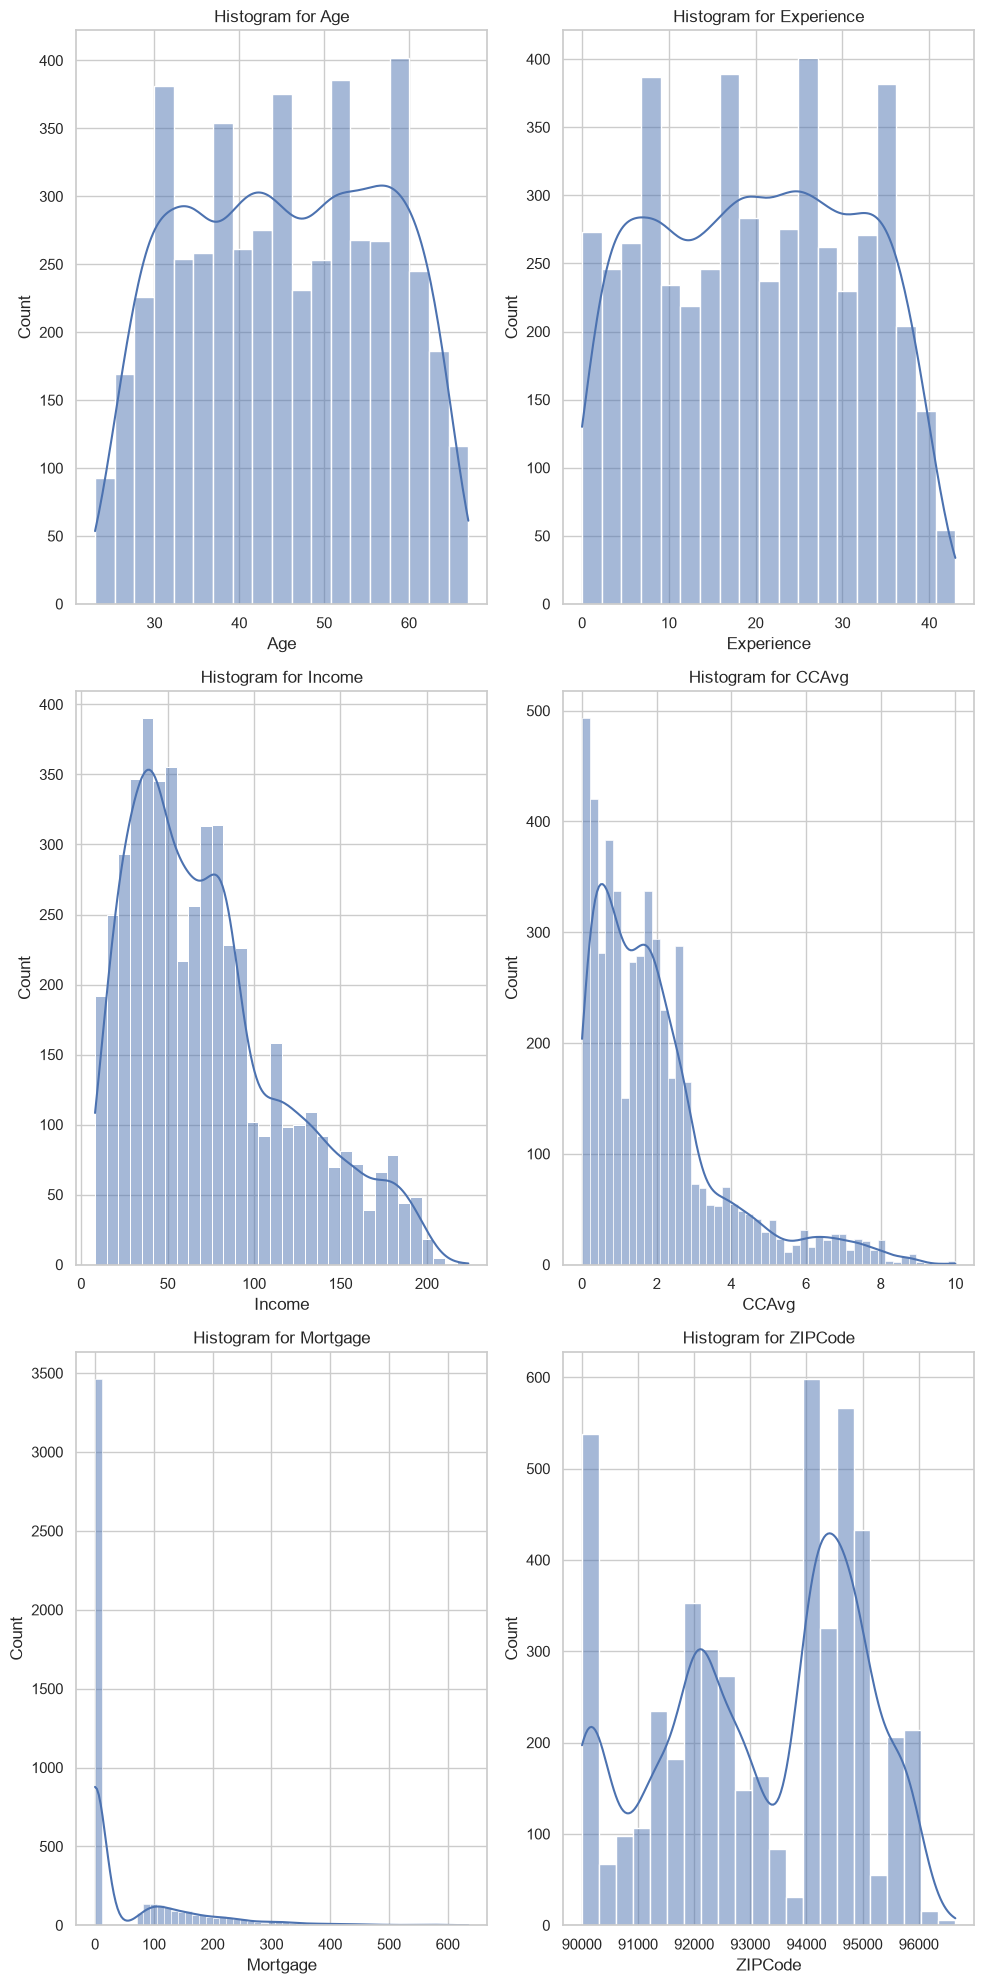

In [12]:
continous_columns = ['Age','Experience','Income','CCAvg','Mortgage','ZIPCode']
fig,axes = plt.subplots(nrows = 3, ncols = 2, figsize = (10,20))
axes_flat = axes.flatten()
for i, col_name in enumerate(continous_columns):
    sns.histplot(x = df[col_name], kde = True, ax = axes_flat[i])
    axes_flat[i].set_title(f'Histogram for {col_name}')
plt.tight_layout()
plt.show()

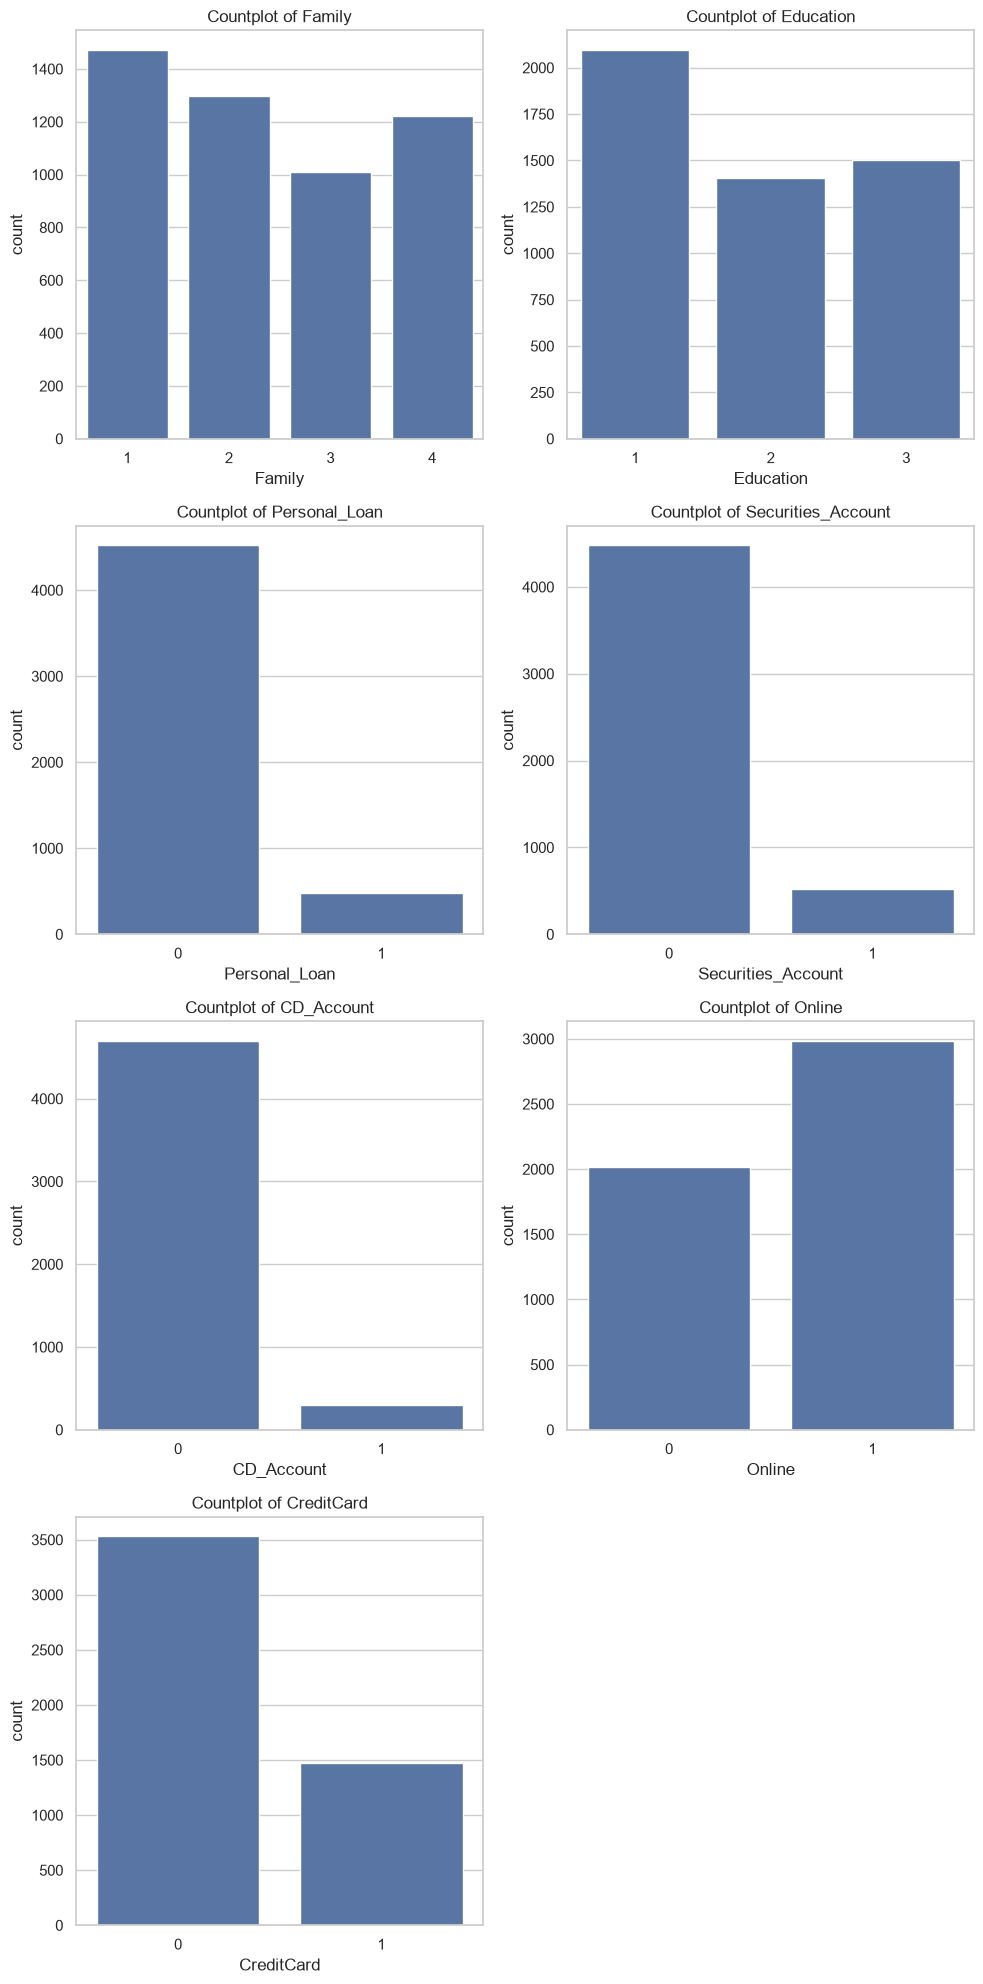

In [13]:
discrete_columns = ['Family','Education','Personal_Loan','Securities_Account','CD_Account','Online','CreditCard']
fig, axes = plt.subplots(nrows = 4, ncols = 2, figsize = (10,20))
axes_flatten = axes.flatten()
for i,col_name in enumerate(discrete_columns):
    sns.countplot(x = df[col_name],ax = axes_flatten[i])
    axes_flatten[i].set_title(f'Countplot of {col_name}')
axes_flatten[7].set_visible(False)
plt.tight_layout()
plt.show()


In [14]:
discrete_columns = ['Family','Education','Personal_Loan','Securities_Account','CD_Account','Online','CreditCard']
for col_name in discrete_columns:
    print(df[col_name].value_counts(normalize= True))
    print("-" * 50)

Family
1    0.2944
2    0.2592
4    0.2444
3    0.2020
Name: proportion, dtype: float64
--------------------------------------------------
Education
1    0.4192
3    0.3002
2    0.2806
Name: proportion, dtype: float64
--------------------------------------------------
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64
--------------------------------------------------
Securities_Account
0    0.8956
1    0.1044
Name: proportion, dtype: float64
--------------------------------------------------
CD_Account
0    0.9396
1    0.0604
Name: proportion, dtype: float64
--------------------------------------------------
Online
1    0.5968
0    0.4032
Name: proportion, dtype: float64
--------------------------------------------------
CreditCard
0    0.706
1    0.294
Name: proportion, dtype: float64
--------------------------------------------------


## Bivariate Analysis

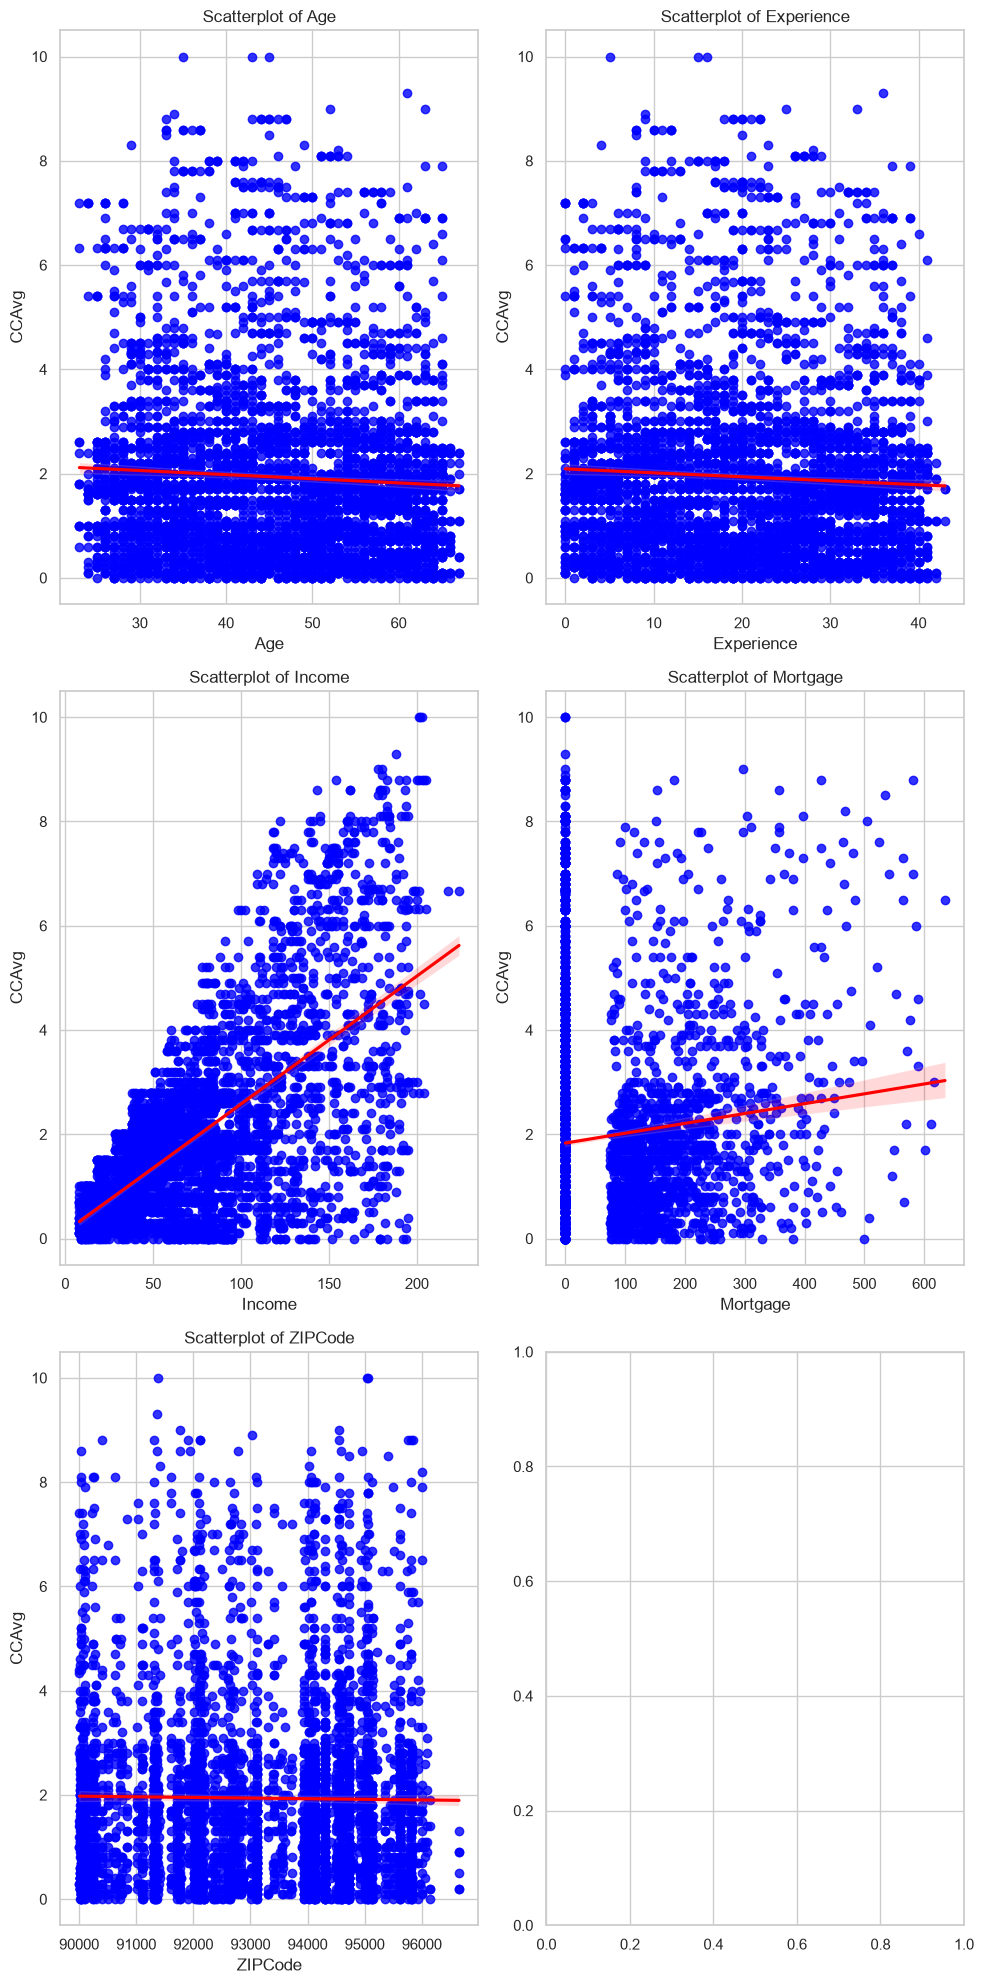

In [15]:
continous_columns = ['Age','Experience','Income','Mortgage','ZIPCode']
fig,axes = plt.subplots(nrows = 3, ncols = 2,figsize = (10,20))
axes_flatten = axes.flatten()
for i, col_name in enumerate(continous_columns):
    sns.regplot(x = col_name, y = 'CCAvg',data = df,ax = axes_flatten[i],scatter_kws = {'color':'blue'},line_kws = {'color':'red'})
    axes_flatten[i].set_title(f'Scatterplot of {col_name}')
    axes_flatten[i].set_xlabel(col_name)
plt.tight_layout()
plt.show()

<Axes: >

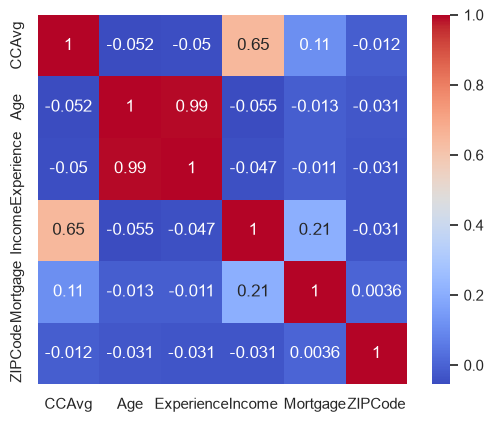

In [16]:
continous_columns = ['CCAvg','Age','Experience','Income','Mortgage','ZIPCode']
correlation_matrix = df[continous_columns].corr()
sns.heatmap(correlation_matrix,
            annot = True,
            cmap = 'coolwarm',
            square = True)

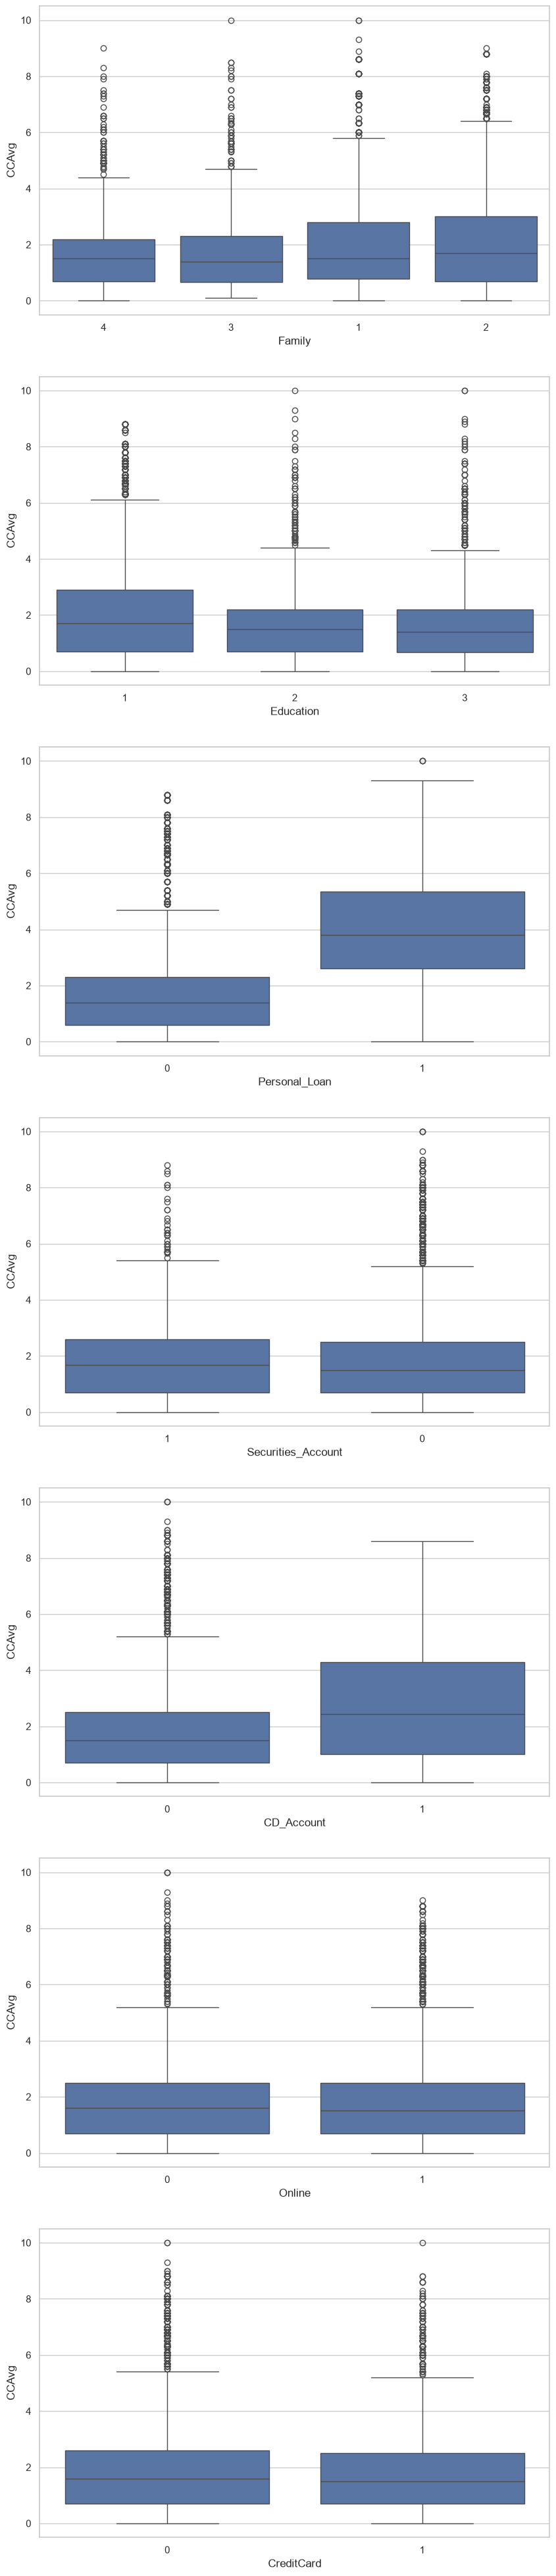

In [17]:
discrete_columns = ['Family','Education','Personal_Loan','Securities_Account','CD_Account','Online','CreditCard']
fig,axes = plt.subplots(nrows = 7, ncols = 1, figsize = (10,50))
axes_flatten = axes.flatten()
for i,col_name in enumerate(discrete_columns):
     sns.boxplot(x = df[col_name].astype(str),y = df['CCAvg'],ax = axes_flatten[i])
#sns.boxplot(x = df['Family'].astype(str),y = df['CCAvg'])

In [19]:
df['ZIPCode'].unique()

array([91107, 90089, 94720, 94112, 91330, 92121, 91711, 93943, 93023,
       94710, 90277, 93106, 94920, 91741, 95054, 95010, 94305, 91604,
       94015, 90095, 91320, 95521, 95064, 90064, 94539, 94104, 94117,
       94801, 94035, 92647, 95814, 94114, 94115, 92672, 94122, 90019,
       95616, 94065, 95014, 91380, 95747, 92373, 92093, 94005, 90245,
       95819, 94022, 90404, 93407, 94523, 90024, 91360, 95670, 95123,
       90045, 91335, 93907, 92007, 94606, 94611, 94901, 92220, 93305,
       95134, 94612, 92507, 91730, 94501, 94303, 94105, 94550, 92612,
       95617, 92374, 94080, 94608, 93555, 93311, 94704, 92717, 92037,
       95136, 94542, 94143, 91775, 92703, 92354, 92024, 92831, 92833,
       94304, 90057, 92130, 91301, 92096, 92646, 92182, 92131, 93720,
       90840, 95035, 93010, 94928, 95831, 91770, 90007, 94102, 91423,
       93955, 94107, 92834, 93117, 94551, 94596, 94025, 94545, 95053,
       90036, 91125, 95120, 94706, 95827, 90503, 90250, 95817, 95503,
       93111, 94132,